## **The hidden geometry of molecules a live statistical demo** for AI&Science Forum 2026 @Khazar University


Packages

In [ ]:
!pip install -q gemmi numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 13.8 MB/s eta 0:00:00


Import and configuration

In [ ]:
import os, io, math, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "font.size": 15,
    "axes.titlesize": 19,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

# Structures(you can add another PDB IDs too : )
PDB_IDS = ["4HHB", "1UBQ", "1LYZ", "1CRN", "3NIR", "2LYZ", "5PTI", "1IGD"]

CACHE = "pdb_cache"
os.makedirs(CACHE, exist_ok=True)
print("Target structures:", ", ".join(PDB_IDS))

Target structures: 4HHB, 1UBQ, 1LYZ, 1CRN, 3NIR, 2LYZ, 5PTI, 1IGD


Fetch : Pull from PDB

In [ ]:
# Mirror technique
MIRRORS = [
    "https://files.rcsb.org/download/{pid}.pdb",
    "https://www.ebi.ac.uk/pdbe/entry-files/download/pdb{pidl}.ent",
]

def fetch_pdb(pid):
    pid = pid.upper()
    local = os.path.join(CACHE, f"{pid}.pdb")
    if os.path.exists(local) and os.path.getsize(local) > 0:
        return local
    for tmpl in MIRRORS:
        url = tmpl.format(pid=pid, pidl=pid.lower())
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "demo"})
            with urllib.request.urlopen(req, timeout=30) as r:
                data = r.read()
            if data:
                with open(local, "wb") as f:
                    f.write(data)
                return local
        except Exception:
            continue
    print(f"  ✗ {pid} Failed to download")
    return None

paths = {}
for pid in PDB_IDS:
    p = fetch_pdb(pid)
    if p:
        paths[pid] = p
        print(f"  ✓ {pid}")
print(f"\n{len(paths)} structure(s) are ready.")

  ✓ 4HHB
  ✓ 1UBQ
  ✓ 1LYZ
  ✓ 1CRN
  ✓ 3NIR
  ✓ 2LYZ
  ✓ 5PTI
  ✓ 1IGD

8 structure(s) are ready.


Geometry: Torsion Angle and Pseudorotation

In [ ]:
import gemmi

def torsion(p1, p2, p3, p4):
    # Dihedral (torsion) angle between four points, in degrees
    b1, b2, b3 = p2 - p1, p3 - p2, p4 - p3
    n1, n2 = np.cross(b1, b2), np.cross(b2, b3)
    m = np.cross(n1, b2 / np.linalg.norm(b2))
    x, y = np.dot(n1, n2), np.dot(m, n2)
    return math.degrees(math.atan2(y, x))

def atom_pos(res, name):
    a = res.find_atom(name, "*")
    return None if a is None else np.array([a.pos.x, a.pos.y, a.pos.z])

def proline_pucker(res):
    # The 5 torsions of the proline ring, along with its phase (P) and amplitude
    P = {n: atom_pos(res, n) for n in ("N", "CA", "CB", "CG", "CD")}
    if any(v is None for v in P.values()):
        return None
    v0 = torsion(P["CD"], P["N"],  P["CA"], P["CB"])
    v1 = torsion(P["N"],  P["CA"], P["CB"], P["CG"])
    v2 = torsion(P["CA"], P["CB"], P["CG"], P["CD"])
    v3 = torsion(P["CB"], P["CG"], P["CD"], P["N"])
    v4 = torsion(P["CG"], P["CD"], P["N"],  P["CA"])
    k = 2 * (math.sin(math.radians(36)) + math.sin(math.radians(72)))
    phase = math.degrees(math.atan2((v4 + v1) - (v3 + v0), v2 * k))
    if phase < 0:
        phase += 360
    cosP = math.cos(math.radians(phase))
    ampl = abs(v2 / cosP) if abs(cosP) > 1e-6 else float("nan")
    return dict(phase=phase, amplitude=ampl, v0=v0, v1=v1, v2=v2, v3=v3, v4=v4)

print("Geometry functions are ready")

Geometry functions are ready


Extract all proline rings

In [ ]:
rows = []
for pid, path in paths.items():
    try:
        st = gemmi.read_structure(path)
    except Exception:
        continue
    model = st[0]
    for chain in model:
        for res in chain:
            if res.name == "PRO":
                r = proline_pucker(res)
                if r:
                    r.update(pdb=pid, chain=chain.name, seqid=res.seqid.num)
                    rows.append(r)

df = pd.DataFrame(rows)
print(f"Found proline ring: {len(df)}")
df.head()

Tapılan prolin halqası: 50


,phase,amplitude,v0,v1,v2,v3,v4,pdb,chain,seqid
0,119.196168,51.974400,-56.209743,45.229330,-25.353178,-0.299511,37.899910,4HHB,A,4
1,11.204066,13.022528,1.403882,-9.065208,12.774336,-12.160704,6.095937,4HHB,A,37
2,8.328409,35.046071,4.148772,-24.800670,34.676478,-28.031076,16.541649,4HHB,A,44
3,205.355286,27.589578,1.905378,11.578967,-24.931867,29.015874,-17.019579,4HHB,A,77
4,161.891981,47.044698,-27.634948,46.064161,-44.714679,28.086097,-0.611316,4HHB,A,95


 Central analysis — distribution

Combine all independent rings and plot the distribution of the phase (P).


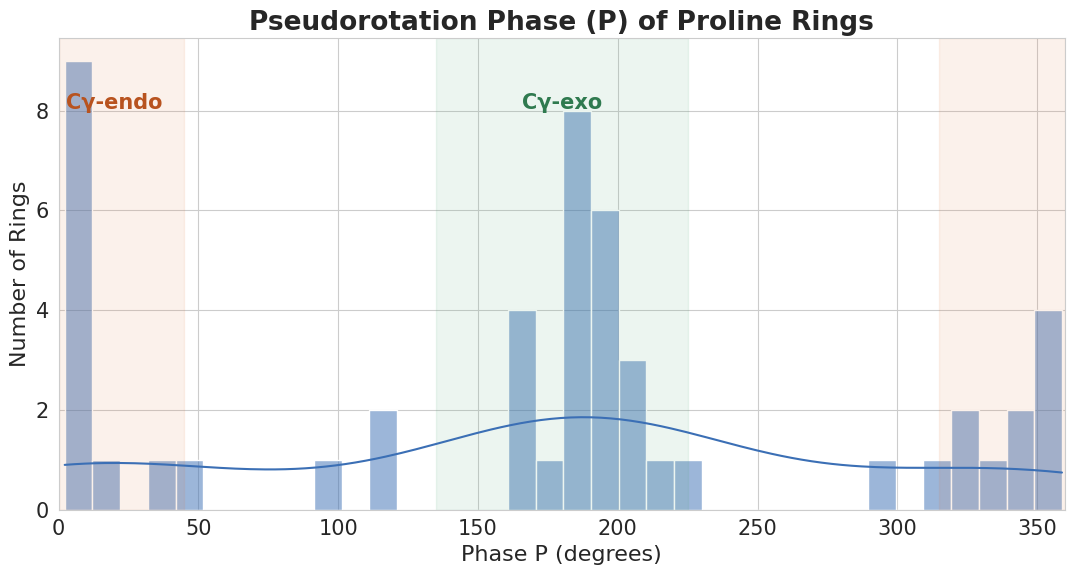

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df["phase"], bins=36, kde=True, color="#3b6fb5",
             edgecolor="white", ax=ax)
ax.axvspan(0,   45,  alpha=0.10, color="#e07a3f")
ax.axvspan(315, 360, alpha=0.10, color="#e07a3f")
ax.axvspan(135, 225, alpha=0.10, color="#4ea674")
ax.text(20,  ax.get_ylim()[1]*0.85, "Cγ-endo",  color="#b8531f", ha="center", fontweight="bold")
ax.text(180, ax.get_ylim()[1]*0.85, "Cγ-exo",   color="#2f7a4f", ha="center", fontweight="bold")
ax.set_title("Pseudorotation Phase (P) of Proline Rings")
ax.set_xlabel("Phase P (degrees)")
ax.set_ylabel("Number of Rings")
ax.set_xlim(0, 360)
plt.tight_layout(); plt.show()

Statistical summary : two hidden conformations

In [ ]:
def cluster(p):
    if p < 90 or p >= 270:
        return "Cγ-endo"
    elif 135 <= p < 225:
        return "Cγ-exo"
    return "intermediate / unusual"

df["state"] = df["phase"].apply(cluster)

summary = (df.groupby("state")
             .agg(count=("phase", "size"),
                  mean_amplitude=("amplitude", "mean"))
             .round(1))

summary["percentage"] = (summary["count"] / len(df) * 100).round(1)

print(summary)

print(f"\nTotal amplitude: mean = {df['amplitude'].mean():.1f}°, "
      f"std = {df['amplitude'].std():.1f}°")

                        count  mean_amplitude  percentage
state                                                    
Cγ-endo                    23            29.1        46.0
Cγ-exo                     23            41.0        46.0
intermediate / unusual      4            36.3         8.0

Total amplitude: mean = 35.1°, std = 23.9°


Two-dimensional view : phase vs amplitude

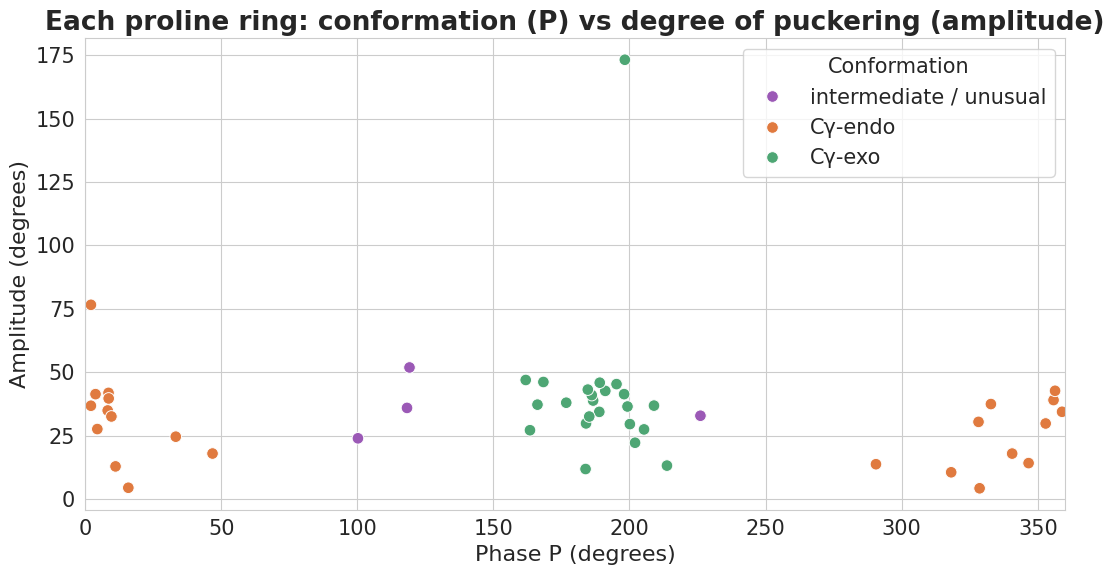

In [ ]:
palette = {"Cγ-endo": "#e07a3f", "Cγ-exo": "#4ea674", "intermediate / unusual": "#9b59b6"}

fig, ax = plt.subplots()

sns.scatterplot(
    data=df,
    x="phase",
    y="amplitude",
    hue="state",
    palette=palette,
    s=70,
    edgecolor="white",
    ax=ax
)

ax.set_title("Each proline ring: conformation (P) vs degree of puckering (amplitude)")
ax.set_xlabel("Phase P (degrees)")
ax.set_ylabel("Amplitude (degrees)")
ax.set_xlim(0, 360)

ax.legend(title="Conformation", loc="upper right")

plt.tight_layout()
plt.show()

Anomaly hunting : statistical deviation


We measure how far each ring’s amplitude deviates from a normal distribution using a z-score. Rings with large |z| values are statistical anomalies.

In [ ]:
mu, sigma = df["amplitude"].mean(), df["amplitude"].std()

df["z"] = (df["amplitude"] - mu) / sigma

outliers = df.reindex(df["z"].abs().sort_values(ascending=False).index)

cols = ["pdb", "chain", "seqid", "state", "phase", "amplitude", "z"]

print("Top 8 strongest statistical anomalies:\n")
print(outliers[cols].head(8).round(2).to_string(index=False))

Top 8 strongest statistical anomalies:

 pdb chain  seqid   state  phase  amplitude     z
4HHB     D     58  Cγ-exo 198.31     173.13  5.76
4HHB     C    114 Cγ-endo   2.17      76.64  1.73
1CRN     A     36 Cγ-endo 328.63       4.40 -1.28
4HHB     B     36 Cγ-endo  15.91       4.61 -1.28
2LYZ     A     79 Cγ-endo 318.19      10.70 -1.02
4HHB     B    100  Cγ-exo 183.87      11.99 -0.97
4HHB     A     37 Cγ-endo  11.20      13.02 -0.92
1LYZ     A     70  Cγ-exo 213.78      13.34 -0.91


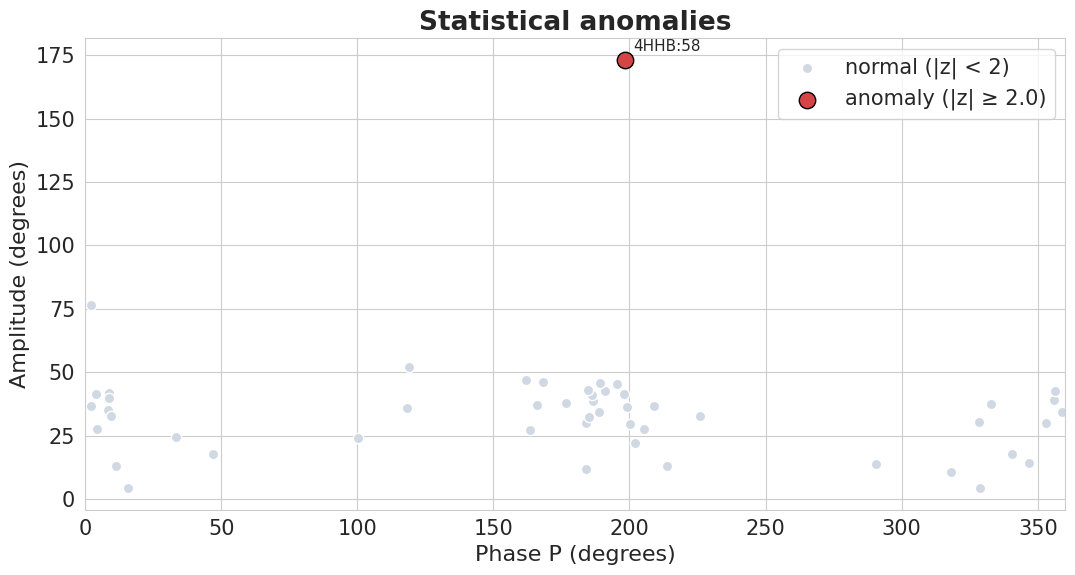

In [ ]:
# Highlight anomalies on the distribution

thr = 2.0

fig, ax = plt.subplots()

ax.scatter(
    df["phase"], df["amplitude"],
    s=55,
    color="#cfd8e3",
    edgecolor="white",
    label="normal (|z| < 2)"
)

hot = df[df["z"].abs() >= thr]

ax.scatter(
    hot["phase"], hot["amplitude"],
    s=140,
    color="#d64545",
    edgecolor="black",
    zorder=5,
    label=f"anomaly (|z| ≥ {thr})"
)

for _, r in hot.iterrows():
    ax.annotate(
        f"{r['pdb']}:{int(r['seqid'])}",
        (r["phase"], r["amplitude"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=11
    )

ax.set_title("Statistical anomalies")
ax.set_xlabel("Phase P (degrees)")
ax.set_ylabel("Amplitude (degrees)")
ax.set_xlim(0, 360)

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()